# Open-Source SAR ADC Modeling

April 2026

SPDX-License-Identifier: Apache License Version 2.0

<br>

**Team members**

|Name|Affiliation|IEEE Member|SSCS Member|
|:--:|:----------:|:----------:|:----------:|
| Alan Gurlaskie (**Team lead**) <br /> Email: alangurlaskie@ufl.edu | University of Florida (USA) | Yes | Yes |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import subprocess
plt.style.use('seaborn-v0_8-whitegrid')

# 4. Global size and font settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})
try:
    import tomllib
except ImportError:
    import tomli as tomllib

## Introduction

Hello! My name is Alan and I am a Master's student in the ECE department at the University of Florida. I am studying Analog/Mixed Signal IC Design and am excited to submit my work for consideration of the Code-a-Chip Travel Grant Award. 

I am currently working to design a Successive Approximation Register (SAR) analog-to-digital converter (ADC) and have spent the past 3-4 months learning many nuances of this seemingly simple circuit. In the process, I discovered a wonderful open-source dynamical system modeling tool called **PathSim** that has helped me gain lots of intuition about the idealized behavior of the SAR ADC. 

With this in mind, the purpose of this notebook is to introduce PathSim and show its potential for the open-source modeling of analog/mixed-signal circuits. 

In particular, this notebook walks through a behavioral model of a differential-input charge redistribution SAR ADC and uses this model to show the impact of several common sources of error including (1) capacitor mismatch, (2) kT/C sampling noise, (3) comparator noise, and (4) CDAC settling error. 

Also, this notebook shows the potential of PathSim to model larger systems. To demonstrate this, the previously discussed SAR ADC model is extended to evaluate a well-known digital background calibration scheme. 

Overall, this notebook aims to show the potential benefits of PathSim for behavioral modeling of open-source analog/mixed-signal circuits, including:

* Preventing designers from "rolling their own" modeling software
    * PathSim already includes several numerical solvers and a fairly intuitive event handling interface, written completely in Python 
* Limiting logical complexity of modeling software
    * The models considered in this notebook are less than 300 lines of code total!
* Providing reusable/extendable circuit models to the community  

## What is PathSim?

PathSim is a _MIT-licensed_ dynamical system simulator written by Milan Rother (see [github](https://github.com/pathsim) and [docs](https://docs.pathsim.org/pathsim/v0.19.0/)). It is fairly new, with its first Github release occurring in 2024. 

Overall, it allows users to assemble complex systems and track their state over time for any arbitrary set of inputs. Its interface is quite flexible and has the capability to model many different types of systems (including analog/mixed-signal circuits).

Also, PathSim has a browser-based companion tool, [PathView](https://view.pathsim.org/), that provides a block diagram interface to connect PathSim models. Due to time constraints, only the basic PathSim scripting interface was explored. 

## Basic SAR Modeling and Simulation in PathSim

### Typical Charge-Redistribution SAR ADC Implementation 

The SAR ADC is widely used to perform analog-to-digital conversion. 

There is an overwhelming amount of information on the web describing its basic operation. In a nutshell, it samples an input voltage and implements a binary search over a set of evenly-spaced voltages to find the voltage that best approximates the sampled input. The size of the input space defines the **resolution** of the ADC. The output of the ADC is a digital code that represents which voltage best approximates the input. 

A typical differential-input charge-redistribution SAR ADC implementation consists of the following circuits:

* Differential-input comparator
* Sampling switches
* Capacitive digital-to-analog converter (CDAC)
* Digital logic circuits to implement the search algorithm and generate the output code

In addition, the ADC requires a reference voltage input and a clock input. 

There are many implementation choices associated with the SAR ADC circuit design. Some typical examples include: (1) whether to sample the input voltage on the top-plate or bottom-plate of the CDAC, (2) how to sequence the digital inputs of the CDAC to generate the required reference voltage (has a large implication on the energy efficiency of the ADC), (3) whether to use synchronous logic implementation (all iterations of binary search algorithm assigned equal time) or an asynchronous logic implementation (comparator output used to determine when to move on to next decision). As discussed in the next section, the implemented PathSim SAR ADC model makes very few assumptions regarding the specific ADC implementation, allowing designers to more easily map the details of their particular implementation to the model. 

### Basic CRSAR PathSim Model Simulations

**Note:** All simulation and model code is included in the `src/` directory.

#### CRSAR Interface/Implementation

The Charge-Redistribution SAR ADC (CRSAR) model implementation is included in `src/crsar.py`.

It has the following I/O interface:

```
Inputs:
    vinp: (+) Differential Input
    vinn: (-) Differential Input
    voffp: (+) Offset Voltage *
    voffn: (-) Offset Voltage *
    samp_en: Sample Enable
    
Outputs:
    vout: Reconstructed version of conversion result in units of V
    dout: Reconstructed version of conversion result in units of LSB
    done: Asserted when the ADC output (vout, dout) is valid
    vcp: (+) Comparator Input (i.e., CDAC (+))
    vcn: (-) Comparator Input (i.e., CDAC (-))
    vcout: Comparator output [1 -> (+) > (-), 0 -> (-) > (+)]
    vinp_samp: Sampled Version of vinp, Updated when done=1
    vinn_samp: Sampled Version of vinn, Updated when done=1
    dout_raw: binary representation of all comparator decisions for a given conversion
```

\* The offset voltage/sample enable inputs are not used until the digital background calibration simulations

The model implementation was guided by the SAR implementation [example](https://github.com/pathsim/pathsim/blob/master/examples/example_sar.py). My implementation includes several error sources and more external visibility into the circuit operation (i.e., more I/O interfaces).

#### Single Conversion - 3-bit SAR ADC

First, a simple simulation is performed, where a 3-bit SAR model repeatedly performs conversions with a constant analog input of -0.4 V with a reference voltage of 1 V. 

With a 1 V reference, the search space contains the following voltages: `[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]`. Since -0.4 V lies between -0.5 V and -0.25 V, the ADC conversion should result in an output code of 2 LSB.

The PathSim simulation is configured in `src/single_conv_3b_sim.py` and the resulting data file is saved to the `data/` directory.

The cells below run the simulation and plot the resulting comparator input and digital output code. As expected, a conversion result of 2 LSB was obtained. 

In [2]:
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b.csv > /dev/null

Text(0, 0.5, 'Digital Code [LSB]')

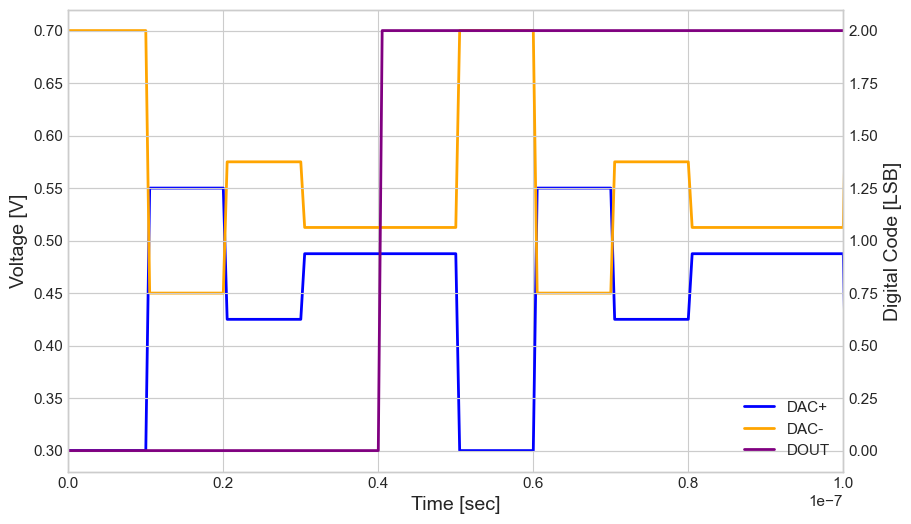

In [5]:
df = './data/single_conv_3b.csv'

dataset = np.genfromtxt(df, delimiter=',', skip_header=1)

t = dataset[:, 0]
compp = dataset[:, 1]
compn = dataset[:, 2]
dout = dataset[:, 4]

fig, ax = plt.subplots()

ax.plot(t, compp, color='blue', label='DAC+')
ax.plot(t, compn, color='orange', label='DAC-')

ax2 = ax.twinx()
ax2.plot(t, dout, color='purple', label='DOUT')

# Collect handles and labels from both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

fs = 20e6
Ts = 1/fs
num_periods = 2
tplot = num_periods*Ts

ax.set_xlim([0, tplot])

# Create a single legend using combined handles and labels
ax2.legend(h1 + h2, l1 + l2, loc='lower right')

ax.set_xlabel('Time [sec]')
ax.set_ylabel('Voltage [V]')
ax2.set_ylabel('Digital Code [LSB]')

#### Dynamic ADC Simulation (Ideal ADC)

As shown above, the model seems to properly perform static simulations of the SAR algorithm. But what happens when a dynamic input is applied?

Another simulation script (`src/dynamic_sim.py`) was written to run a block of conversions with a sine wave input. To evaluate the performance of the ADC, standard FFT-based spectral analysis techniques are employed.

**Note**: There are special considerations when evaluating the dynamic performance of an ADC in simulation:

1. To perform spectral analysis, an integer number of periods of the input signal must be captured. Otherwise, the discrete Fourier transform produces **spectral leakage**, corrupting FFT-based performance estimates
2. To evaluate the performance of the converter, care should be taken to maximize the number of unique codes produced by the ADC. Consider an input at half of the nyquist frequency. Since the period of the input signal is 4 samples, an ideal ADC will produce the same four results over and over again. This clearly does not give a good representation of the performance of the converter, as it does not evaluate the majority of output codes (they could have completed incorrect behavior and we would have no idea!). Instead, to maximize the number of codes for a given block size, the input frequency should be chosen to be (M/N)*fs where N is the block size and M and N share no common factors.

Together, these constraints define what is commonly known as **coherent sampling**. In `dynamic_sim.py`, N and M are specified through the `-N` and `-M` arguments. 

**SFDR** (spurious free dynamic range) and **SNDR** (signal to noise and distortion ratio) are common metrics used to characterize the dynamic performance of ADCs. Some helper functions are given below to compute these quantities and post-process the simulation results.

In [7]:
def compute_dynamic_performance(time_series, f_clk, N, M):
    
    # N point FFT starting at first ADC sample
    window = 'boxcar'
    
    nfft = N
    nperseg = N
    scaling = 'spectrum'
    
    f, csd = signal.csd(time_series, time_series, fs=f_clk, 
                        window=window, nperseg=nperseg, nfft=nfft,
                        scaling=scaling)

    delta=1e-25 # prevent bins with absolutely 0 bins (no divide by 0 in log)
    fft_result  = np.sqrt(np.abs(csd[1:])) + delta
    fft_freq = f[1:]
    fft_signal_bin = M - 1
    fft_normalized = (fft_result * np.sqrt(2)) / (2**(n-1)) 
    
    # compute SNDR and SFDR
    sndr = np.sqrt(fft_result[fft_signal_bin]**2 / \
                   (np.sum(fft_result**2) - fft_result[fft_signal_bin]**2))
    sfdr = fft_result[fft_signal_bin] / \
        np.max(np.delete(fft_result, fft_signal_bin))

    return fft_freq, fft_normalized, sndr, sfdr

In [8]:
def bulk_dynamic_sim_analysis(path_to_df, res, n, N, M, f_clk=20e6, 
                              td_tstart=None, td_tstop=None, fig_title=None,
                             plot_enable=True):
    dataset = np.genfromtxt(df, delimiter=',', skip_header=1)
    
    t = dataset[:, 0]
    vout = dataset[:, 1]
    vin = dataset[:, 2]
    done = dataset[:, 3]
    dout = dataset[:, 4]

    tstart = td_tstart if td_tstart is not None else min(t)
    tstop = td_tstop if td_tstop is not None else max(t)
    idx_start = np.argmin(np.abs(t-tstart))
    idx_stop = np.argmin(np.abs(t-tstop))    

    # find which times done experiences rising edge (convesion results ready)
    transitions = np.where(np.diff(done) == 1)[0] + 1

    # get unique dout samples for FFT analysis
    dout_samp = dout[transitions]

    samples_to_skip = 0
    time_series = dout_samp[samples_to_skip:samples_to_skip+N].astype('float')
    fft_freq, fft_normalized, sndr, sfdr = compute_dynamic_performance(time_series,
                                                                      f_clk, N, M)
    if plot_enable:
        # plot sample time domain waveforms
        fig, axs = plt.subplots(3, 1)
        axs[0].plot(t[idx_start:idx_stop], vin[idx_start:idx_stop], label='Vin')
        axs[0].plot(t[idx_start:idx_stop], vout[idx_start:idx_stop], label='Vout')
        axs[0].legend()
        axs[0].set_title(f'{res} SAR - Time Domain I/O')
        axs[0].set_xlabel('Time [sec]')
        axs[0].set_ylabel('Voltage [V]')
    
        # plot quantization error
        axs[1].plot(t, vout-vin)
        axs[1].set_title(f'{res} SAR - Time Domain Quantization Error')
        axs[1].set_xlabel('Time [sec]')
        axs[1].set_ylabel('Voltage [V]')
        
        # plot FFT
        axs[2].plot(fft_freq, 20*np.log10(fft_normalized))
        axs[2].set_title(f'{res} SAR - SNDR: {20*np.log10(sndr):.2f} dB, SFDR: {20*np.log10(sfdr):.2f} dB')
        axs[2].set_ylim([-120, 5])
        axs[2].set_xlabel('Frequency [Hz]')
        axs[2].set_ylabel('FFT [dBFS]')
        
        if fig_title is not None:
            fig.suptitle(fig_title, fontsize=16)
        
        fig.tight_layout()    

    return sndr, sfdr

Below, the `dynamic_sim.py` script is evaluated for ideal 4-bit, 8-bit, and 12-bit ADCs (N=16384, M=511).

In [6]:
!python ./src/dynamic_sim.py -n 4 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_4b.csv > /dev/null
!python ./src/dynamic_sim.py -n 8 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_8b.csv > /dev/null
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_12b.csv > /dev/null

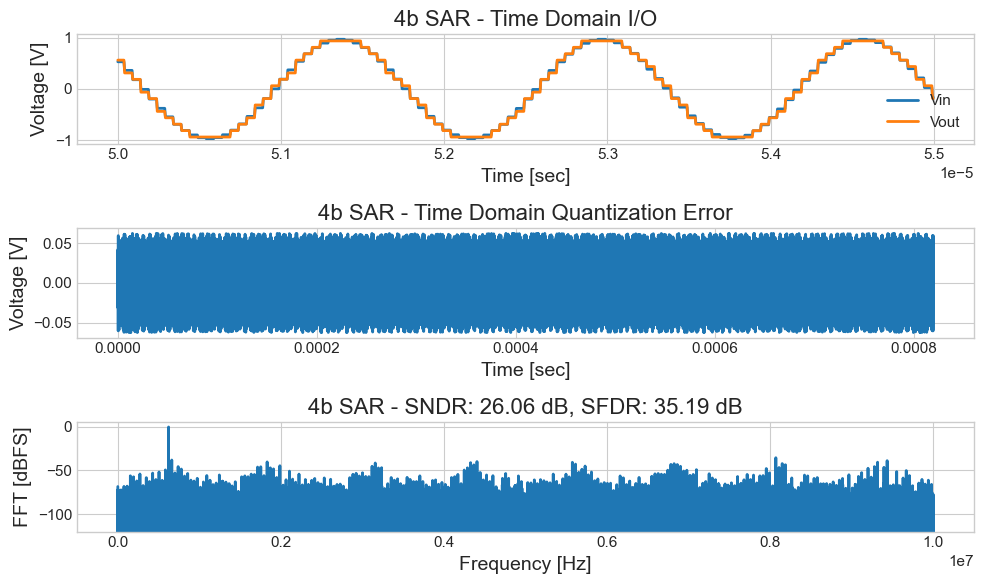

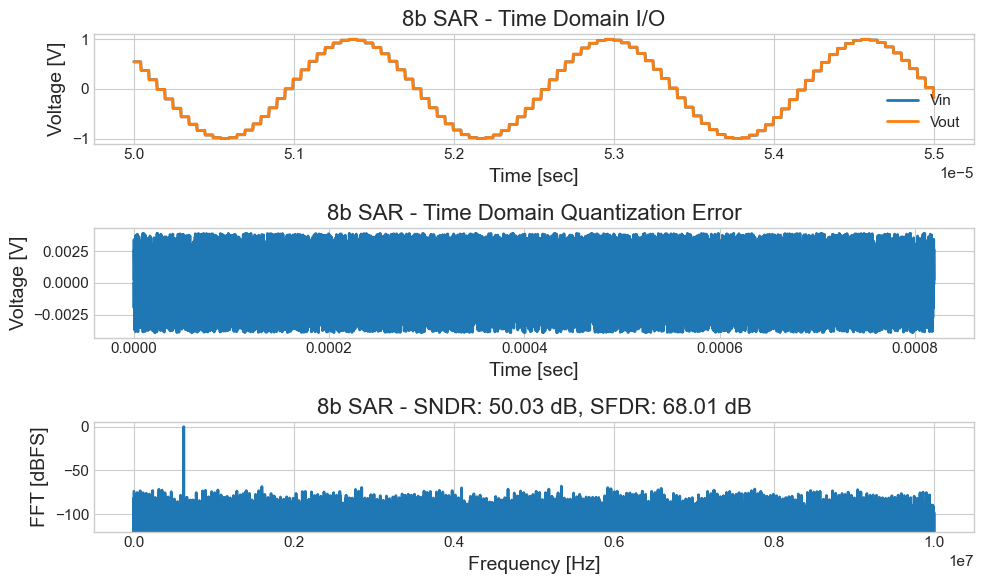

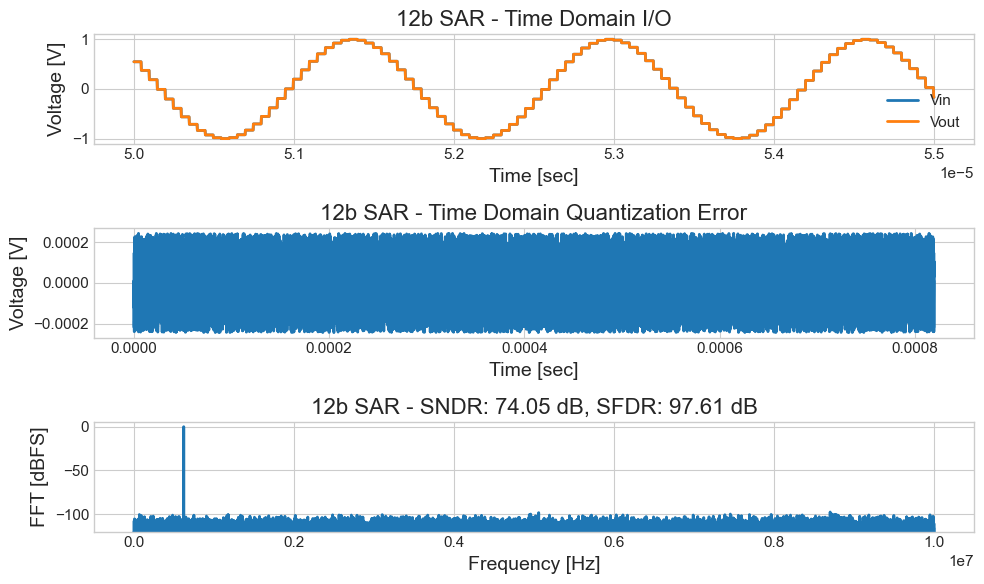

In [9]:
datafiles = ['./data/ideal_dynamic_sim_4b.csv',
            './data/ideal_dynamic_sim_8b.csv',
            './data/ideal_dynamic_sim_12b.csv']

N = 16384
M = 511
f_clk = 20e6

for df in datafiles:
    res = df.rsplit('_', 1)[-1].split('.')[0] # extract number of bits from filename
    nstr, _ = res.split('b')
    n = int(nstr)
    td_tstart = 50e-6
    td_tstop = 55e-6
    bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop)

For an ideal N-bit converter, the SNDR is limited by the number of quantization levels.

In particular, the expected SNDR for an n-bit converter is given by the familiar formula: 6.02*N + 1.76 dB.

The ideal value is printed below for each tested ADC resolution.

In [45]:
n = np.array([4, 8, 12])
print(6.02*n + 1.76)

[25.84 49.92 74.  ]


As shown, the implemented SAR model produces a SNDR within 0.25 dB of the ideal value for each ADC resolution.

## Simulating SAR ADC Error Sources

### Capacitor Mismatch

Up to this point, the set of voltages used to compare the input against was assumed to be ideal. 

However, in practice, these voltages must be generated by the CDAC and their accuracy depends on the accuracy of the capacitor values in the capacitor array. In the literature, a weight vector $w$ is introduced to represent the "weight" of each decision in the execution of the binary search algorithm. If the true values of the capacitors in the CDAC are known, they can be easily mapped to a set of weights (the mapping is dependent on the CDAC topology/values).

For a standard SAR ADC, the weight associated with each decision is $\frac{1}{2}^{i}$ where $i$ is the index of the decision. However, due to random mismatch/parasitics, the true weight associated with each decision will deviate from the ideal value. Overall, this will result in non-linearities in the ADC transfer characteristic. To simulate this effect, the `CRSAR` PathSim model includes two parameters `estimated_weights` and `actual_weights`.

* `estimated_weights` is the set of weights that is assumed by the converter and used to convert the raw comparator decisions into `vout` and `dout`
* `actual_weights` is the set of weights used to generate update the CDAC outputs

A common way to implement a n-bit CDAC is to combine $2^n$ unit capacitors to construct capacitors of value: $2^{n-1}$, $2^{n-2}$, $2^{n-3}$, etc. A helper script was written to generate `estimated_weights` and `actual_weights` for this particular case. The script, called `generalize_weights.py`, accepts the unit capacitor value, the standard deviation of the unit capacitor value, and the number of bits and produces the two required `.npy` files. 

The script is run below for a unit capacitor value of 10 fF and a standard deviation of 2 fF. 

In [10]:
!python ./src/generate_weights.py -n 12 -r 2 -u 1e-14 -s 2e-15 -o ./config > /dev/null

The resulting weights are printed below.

In [11]:
weights_filepaths = [
    './config/weights_estimated_12b_radix2_00.npy',
    './config/weights_actual_12b_radix2_00.npy'
]

for fp in weights_filepaths:
    print(fp)
    print(np.load(fp))
    print('--------------------')

./config/weights_estimated_12b_radix2_00.npy
[5.00000000e-01 2.50000000e-01 1.25000000e-01 6.25000000e-02
 3.12500000e-02 1.56250000e-02 7.81250000e-03 3.90625000e-03
 1.95312500e-03 9.76562500e-04 4.88281250e-04 2.44140625e-04]
--------------------
./config/weights_actual_12b_radix2_00.npy
[4.99711309e-01 2.50755717e-01 1.25101636e-01 6.13527071e-02
 3.16834218e-02 1.57661635e-02 7.64808030e-03 4.01130232e-03
 1.99926472e-03 1.00317382e-03 4.89213678e-04 2.70266447e-04]
--------------------


Next, `dynamic_sim.py` is run for a 12-bit ADC, whose only non-ideality is the mismatch in weights.

In [12]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -o ./data/capacitor_mismatch_sim.csv \
-wa ./config/weights_actual_12b_radix2_00.npy \
-we ./config/weights_estimated_12b_radix2_00.npy \
> /dev/null

From the plot below, a large degradation in SFDR and SNDR was observed due to non-linearity of the CDAC. 

(np.float64(526.3997479023428), np.float64(1267.1912346769045))

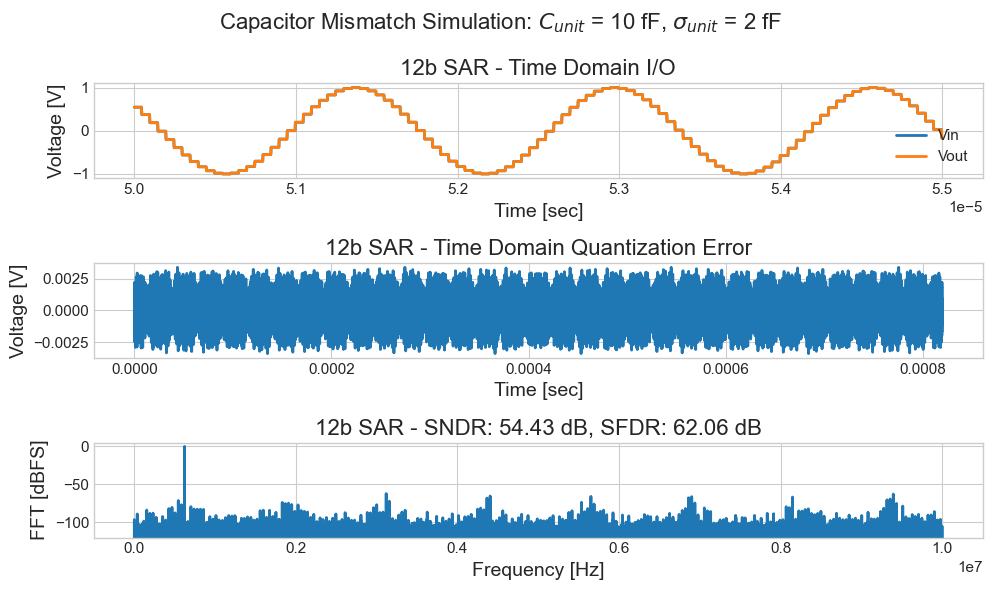

In [13]:
df = './data/capacitor_mismatch_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'Capacitor Mismatch Simulation: $C_{unit}$ = 10 fF, $\sigma_{unit}$ = 2 fF'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

### kT/C Sampling Noise

In discrete-time sampling circuits, switches are used to connect the input to a sampling capacitor and remove it once the sampling process is complete. Though the sampling capacitor does not produce any noise, the switch generates noise since it has an internal resistance. It can be shown that the power of the noise deposited onto the sampling capacitor is independent of the switch resistance and equal to $kT/C$. 

The `CRSAR` model simulates the effect of this noise through a `total_sampling_cap` parameter. If specified, the model samples a Gaussian distribution with the specified variance twice and adds a random sample to each side of the differential input each time a new input is sampled. In this implementation, `total_sampling_cap` is the sampling capacitance for each differential leg (i.e., the distribution is sampled twice per conversion; one sample is added to the (+) DAC value and the other sample is added to the (-) DAC value.

Below, the effect of this is shown for a 12-bit SAR ADC with a total of 1 mVrms kT/C noise.

In [14]:
k = 1.38e-23
T = 300
kTC_noise_rms_total = 1e-3 # 1 mVrms
kTC_noise_rms_se = kTC_noise_rms_total/np.sqrt(2)
C_eq = k*T/(kTC_noise_rms_se**2)
print(C_eq)

8.28e-15


In [15]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -sc 8.28e-15 \
-o ./data/kTC_noise_1mVrms_sim.csv > /dev/null

(np.float64(705.8595174714796), np.float64(21407.04372344292))

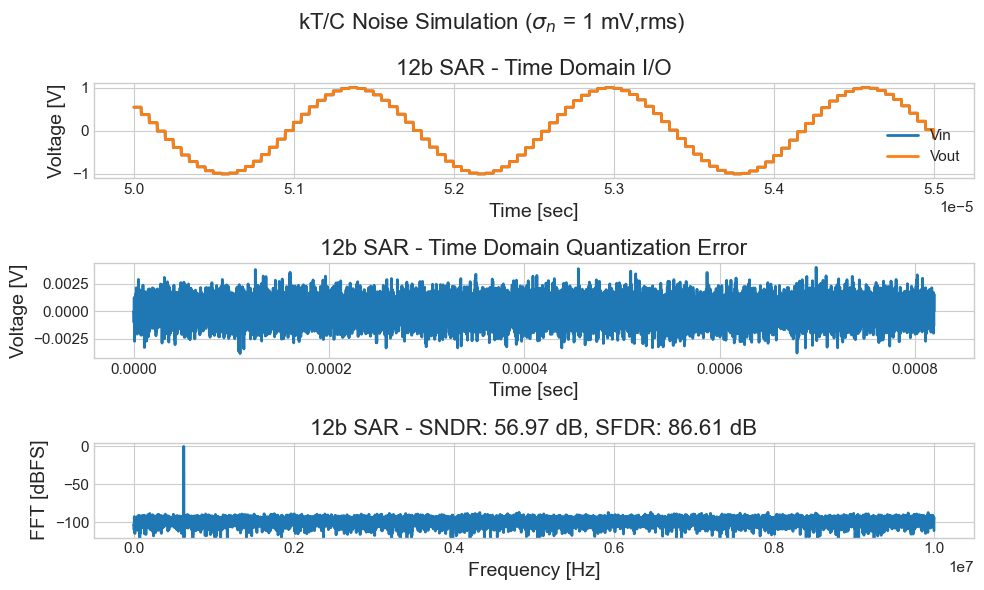

In [16]:
df = './data/kTC_noise_1mVrms_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'kT/C Noise Simulation ($\\sigma_{n}$ = 1 mV,rms)'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

Next, several values of kT/C noise are evaluated. 

From a design perspective, this sweep shows how the performance of the ADC is affected by the value of sampling capacitance. 

In [17]:
kTC_noise_rms = np.logspace(start=-5, stop=-2, num=30)
kTC_noise_rms_se = kTC_noise_rms/np.sqrt(2)
samp_caps = k*T/(kTC_noise_rms_se**2)
N = 4096
M = 13
n = 12
f_clk = 20e6

k = 1.38e-23
T = 300

sndr = np.zeros(kTC_noise_rms.shape)

for i, cap in enumerate(samp_caps):
    print(f'Total kT/C Noise: {kTC_noise_rms[i]} Vrms')
    print(f'Total Sampling Capacitance: {cap} F')

    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/kTC_noise_sweep_{int(kTC_noise_rms[i]*1e6)}uVrms.csv",
        "-sc", str(cap)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/kTC_noise_sweep_{int(kTC_noise_rms[i]*1e6)}uVrms.csv"
    sndr[i], _ = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Total kT/C Noise: 1e-05 Vrms
Total Sampling Capacitance: 8.28e-11 F
Total kT/C Noise: 1.2689610031679234e-05 Vrms
Total Sampling Capacitance: 5.14202027886212e-11 F
Total kT/C Noise: 1.610262027560939e-05 Vrms
Total Sampling Capacitance: 3.193281708723356e-11 F
Total kT/C Noise: 2.0433597178569438e-05 Vrms
Total Sampling Capacitance: 1.983082041349635e-11 F
Total kT/C Noise: 2.592943797404667e-05 Vrms
Total Sampling Capacitance: 1.2315275448390278e-11 F
Total kT/C Noise: 3.290344562312671e-05 Vrms
Total Sampling Capacitance: 7.647994697511547e-12 F
Total kT/C Noise: 4.1753189365604006e-05 Vrms
Total Sampling Capacitance: 4.749534278651508e-12 F
Total kT/C Noise: 5.2983169062837125e-05 Vrms
Total Sampling Capacitance: 2.9495412531372984e-12 F
Total kT/C Noise: 6.723357536499335e-05 Vrms
Total Sampling Capacitance: 1.8317150890063336e-12 F
Total kT/C Noise: 8.531678524172815e-05 Vrms
Total Sampling Capacitance: 1.1375261029913402e-12 F
Total kT/C Noise: 0.00010826367338740541 Vrms
Total 

Text(0, 0.5, '[dB]')

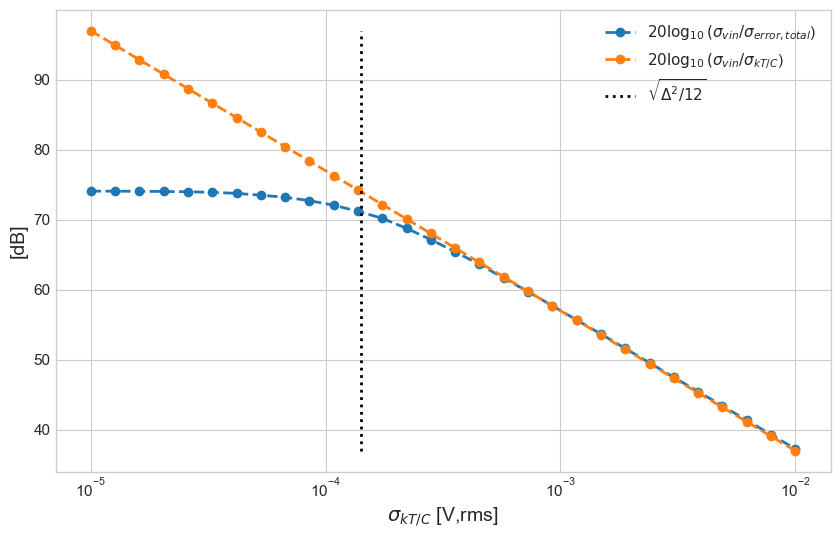

In [18]:
fig, ax = plt.subplots()

ax.plot(kTC_noise_rms, 20*np.log10(sndr), linestyle='dashed', 
       marker='o', label='$20\\log_{10}(\\sigma_{vin} / \\sigma_{error,total}$)')

n = 12
vref = 1.0
vlsb = 2*vref / (2 ** n)
qe = np.sqrt(vlsb**2 / 12)
vd_peak = vref-(vlsb/2)
vd_rms = vd_peak / np.sqrt(2)

eq_sndr_vin_kTC = 20*np.log10(vd_rms/kTC_noise_rms)
ax.plot(kTC_noise_rms, eq_sndr_vin_kTC, 
        linestyle='dashed', marker='o', 
        label='$20\\log_{10}(\\sigma_{vin} / \\sigma_{kT/C}$)')

ax.vlines(x=qe, ymin=min(eq_sndr_vin_kTC), 
          ymax=max(eq_sndr_vin_kTC), linestyle='dotted', color='black', 
          label='$\\sqrt{\\Delta^2/12}$')

ax.set_xscale('log')
ax.legend()

ax.set_xlabel('$\\sigma_{kT/C}$ [V,rms]')
ax.set_ylabel('[dB]')

### Comparator Input Noise

Next, errors due to comparator input noise are considered. Another parameter is introduced into the `dynamic_sim.py` script to set the comparator noise in $V_{rms}$. The simulation below assumes an RMS comparator noise of 1 mV,rms.

In [19]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -cn 1e-3 \
-o ./data/comp_noise_1mVrms_sim.csv > /dev/null

The results of the dynamic simulation are shown below. As expected, the SNDR is degraded from the ideal case with no comparator noise. 

(np.float64(892.7129119368021), np.float64(25222.280844729536))

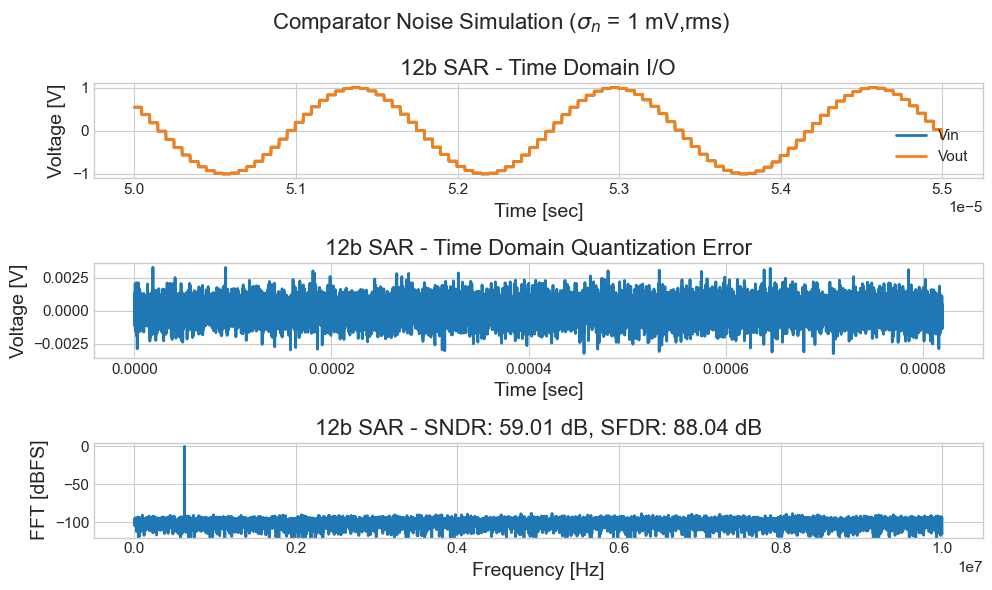

In [20]:
df = './data/comp_noise_1mVrms_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'Comparator Noise Simulation ($\\sigma_{n}$ = 1 mV,rms)'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

Next, a sweep of RMS comparator noise is performed.

In [21]:
comparator_noise_rms = np.logspace(start=-5, stop=-2, num=30)

N = 4096
M = 13
n = 12
f_clk = 20e6

sndr = np.zeros(comparator_noise_rms.shape)

for i, cn in enumerate(comparator_noise_rms):
    print(f'Comparator Noise: {cn} Vrms')
    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/comp_noise_sweep_{int(cn*1e9)}nVrms.csv",
        "-cn", str(cn)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/comp_noise_sweep_{int(cn*1e9)}nVrms.csv"
    sndr[i], _ = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Comparator Noise: 1e-05 Vrms
Comparator Noise: 1.2689610031679234e-05 Vrms
Comparator Noise: 1.610262027560939e-05 Vrms
Comparator Noise: 2.0433597178569438e-05 Vrms
Comparator Noise: 2.592943797404667e-05 Vrms
Comparator Noise: 3.290344562312671e-05 Vrms
Comparator Noise: 4.1753189365604006e-05 Vrms
Comparator Noise: 5.2983169062837125e-05 Vrms
Comparator Noise: 6.723357536499335e-05 Vrms
Comparator Noise: 8.531678524172815e-05 Vrms
Comparator Noise: 0.00010826367338740541 Vrms
Comparator Noise: 0.00013738237958832637 Vrms
Comparator Noise: 0.00017433288221999874 Vrms
Comparator Noise: 0.000221221629107045 Vrms
Comparator Noise: 0.0002807216203941176 Vrms
Comparator Noise: 0.0003562247890262444 Vrms
Comparator Noise: 0.00045203536563602405 Vrms
Comparator Noise: 0.0005736152510448681 Vrms
Comparator Noise: 0.0007278953843983146 Vrms
Comparator Noise: 0.0009236708571873865 Vrms
Comparator Noise: 0.0011721022975334804 Vrms
Comparator Noise: 0.0014873521072935117 Vrms
Comparator Noise: 0

The SNDR is plotted against the RMS comparator noise below. From a practical perspective, it is apparent that keeping the comparator noise below the quantization noise level will avoid severely degrading the ADC performance. 

Text(0, 0.5, '[dB]')

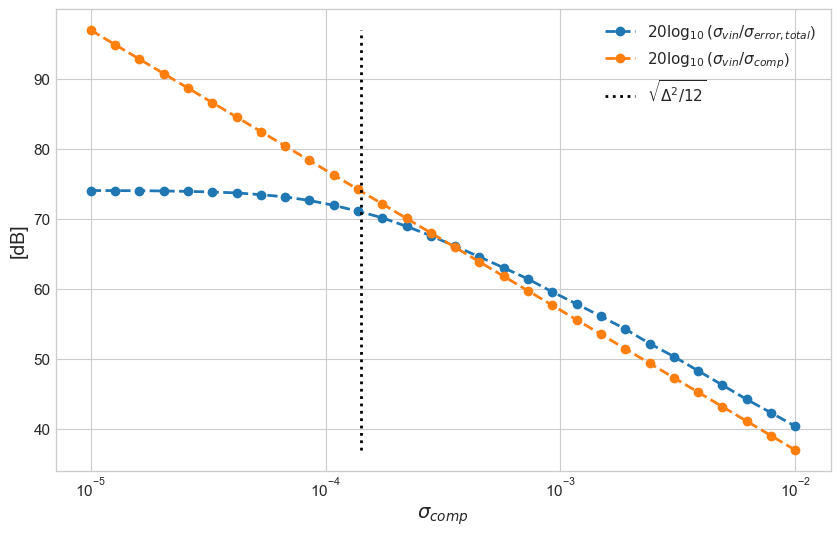

In [22]:
comparator_noise_rms = np.logspace(start=-5, stop=-2, num=30)
fig, ax = plt.subplots()

ax.plot(comparator_noise_rms, 20*np.log10(sndr), linestyle='dashed', 
       marker='o', label='$20\\log_{10}(\\sigma_{vin} / \\sigma_{error,total}$)')

n = 12
vref = 1.0
vlsb = 2*vref / (2 ** n)
qe = np.sqrt(vlsb**2 / 12)
vd_peak = vref-(vlsb/2)
vd_rms = vd_peak / np.sqrt(2)

eq_sndr_vin_comp = 20*np.log10(vd_rms/comparator_noise_rms)
ax.plot(comparator_noise_rms, eq_sndr_vin_comp, 
        linestyle='dashed', marker='o',
       label='$20\\log_{10}(\\sigma_{vin} / \\sigma_{comp}$)')

ax.vlines(x=qe, ymin=min(eq_sndr_vin_comp), 
          ymax=max(eq_sndr_vin_comp), linestyle='dotted', color='black',
         label='$\\sqrt{\\Delta^2/12}$')

ax.legend()
ax.set_xscale('log')

ax.set_xlabel('$\\sigma_{comp}$')
ax.set_ylabel('[dB]')

### CDAC Settling Error

Another common source of error in SAR ADCs is CDAC settling error. Essentially, depending on the implementation of the SAR logic, it is possible that the comparator input (CDAC voltage) has not fully settled to its final value when a comparison is performed. For DAC voltages close to the comparator threshold voltage, this can cause decision errors leading to conversion errors. This is illustrated below for the previous 3-bit conversion example. 

Two simulations are performed, one with 10% CDAC settling error and one with 25% settling error with a differential input of -0.4 V and a reference voltage of 1 V. The time domain plots are shown below illustrate that with 10% error, there are no decision errors. However, for a settling error of 25%, the digital output of th ADC is incorrect.

In [23]:
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b_se_10pct.csv -se 10 > /dev/null
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b_se_25pct.csv -se 25 > /dev/null

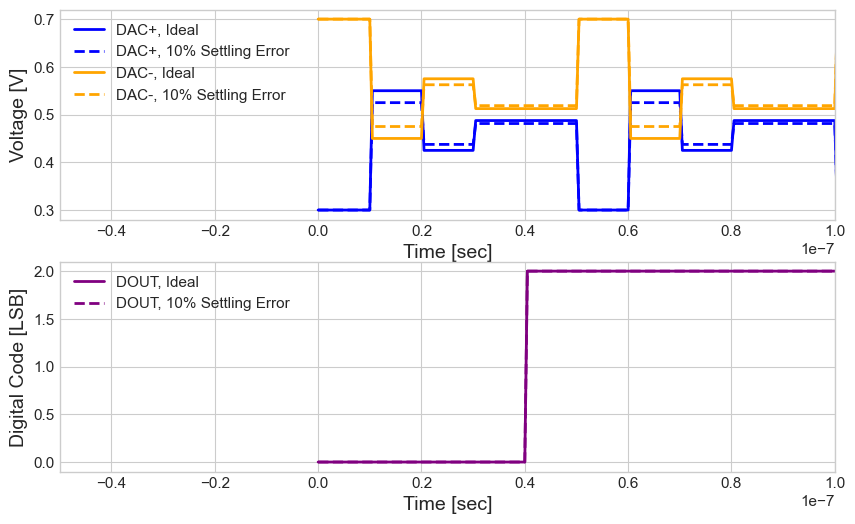

In [24]:
ideal_df = './data/single_conv_3b.csv'
se_df = './data/single_conv_3b_se_10pct.csv'

ideal_dataset = np.genfromtxt(ideal_df, delimiter=',', skip_header=1)
se_dataset = np.genfromtxt(se_df, delimiter=',', skip_header=1)

ideal_t = ideal_dataset[:, 0]
ideal_compp = ideal_dataset[:, 1]
ideal_compn = ideal_dataset[:, 2]
ideal_dout = ideal_dataset[:, 4]
se_t = se_dataset[:, 0]
se_compp = se_dataset[:, 1]
se_compn = se_dataset[:, 2]
se_dout = se_dataset[:, 4]

fig, axs = plt.subplots(2, 1)

axs[0].plot(ideal_t, ideal_compp, color='blue', label='DAC+, Ideal')
axs[0].plot(se_t, se_compp, linestyle='dashed', color='blue', label='DAC+, 10% Settling Error')
axs[0].plot(ideal_t, ideal_compn, color='orange', label='DAC-, Ideal')
axs[0].plot(se_t, se_compn, linestyle='dashed', color='orange', label='DAC-, 10% Settling Error')
axs[0].set_ylabel('Voltage [V]')

axs[1].plot(ideal_t, ideal_dout, color='purple', label='DOUT, Ideal')
axs[1].plot(se_t, se_dout, color='purple', linestyle='dashed', label='DOUT, 10% Settling Error')
axs[1].set_ylabel('Digital Code [LSB]')

fs = 20e6
Ts = 1/fs
num_periods = 2
tplot = num_periods*Ts
for ax in axs:
    ax.set_xlim([-tplot/2, tplot])
    ax.set_xlabel('Time [sec]')
    ax.legend()

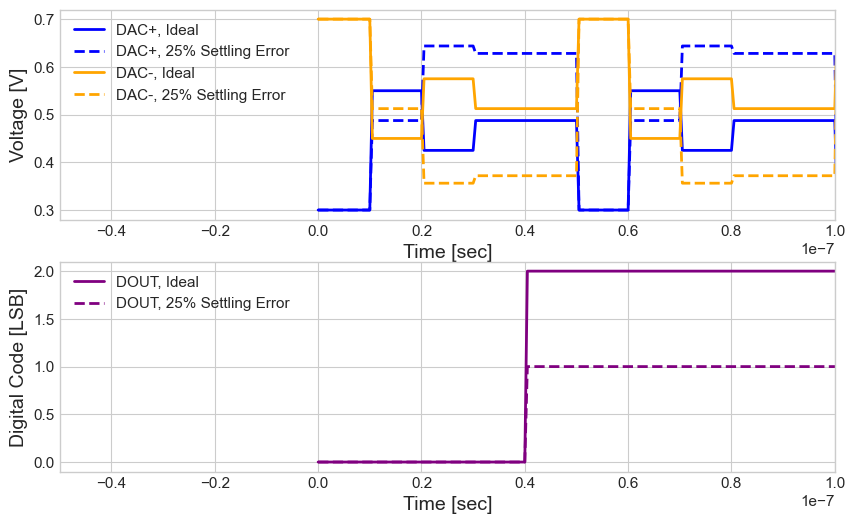

In [25]:
ideal_df = './data/single_conv_3b.csv'
se_df = './data/single_conv_3b_se_25pct.csv'

ideal_dataset = np.genfromtxt(ideal_df, delimiter=',', skip_header=1)
se_dataset = np.genfromtxt(se_df, delimiter=',', skip_header=1)

ideal_t = ideal_dataset[:, 0]
ideal_compp = ideal_dataset[:, 1]
ideal_compn = ideal_dataset[:, 2]
ideal_dout = ideal_dataset[:, 4]
se_t = se_dataset[:, 0]
se_compp = se_dataset[:, 1]
se_compn = se_dataset[:, 2]
se_dout = se_dataset[:, 4]


fig, axs = plt.subplots(2, 1)

axs[0].plot(ideal_t, ideal_compp, color='blue', label='DAC+, Ideal')
axs[0].plot(se_t, se_compp, linestyle='dashed', color='blue', label='DAC+, 25% Settling Error')
axs[0].plot(ideal_t, ideal_compn, color='orange', label='DAC-, Ideal')
axs[0].plot(se_t, se_compn, linestyle='dashed', color='orange', label='DAC-, 25% Settling Error')
axs[0].set_ylabel('Voltage [V]')

axs[1].plot(ideal_t, ideal_dout, color='purple', label='DOUT, Ideal')
axs[1].plot(se_t, se_dout, color='purple', linestyle='dashed', label='DOUT, 25% Settling Error')
axs[1].set_ylabel('Digital Code [LSB]')

fs = 20e6
Ts = 1/fs
num_periods = 2
tplot = num_periods*Ts
for ax in axs:
    ax.set_xlim([-tplot/2, tplot])
    ax.set_xlabel('Time [sec]')
    ax.legend()

Since settling error is largely unavoidable, circuit modifications are used to mitigate this error. In particular, redundancy is introduced into the SAR algorithm to ensure that the algorithm can still find the optimum approximation for the input voltage even if there is an erroneous decision due to settling error. 

One way to achieve this redundancy is to use a **sub-radix-2** CDAC and perform more than $n$ decisions per conversion. Sample weights for a radix-1.86 CDAC with 15 decisions are generated and printed below.

In [26]:
!python ./src/generate_weights.py -n 15 -r 1.86 -u 1e-14 -s 5e-15 -o ./config > /dev/null

In [27]:
fp = './config/weights_estimated_15b_radix1_86.npy'
print(fp)
print(np.load(fp))

./config/weights_estimated_15b_radix1_86.npy
[4.62407503e-01 2.48606184e-01 1.33659239e-01 7.18598058e-02
 3.86343042e-02 2.07711313e-02 1.11672749e-02 6.00391123e-03
 3.22790926e-03 1.73543509e-03 9.33029617e-04 5.01628826e-04
 2.69692917e-04 1.44996192e-04 7.79549420e-05]


Next, the SNDR and SFDR of the standard SAR and the SAR with redundancy are compared for several values of settling error. As shown, the SNDR and SFDR immediately decrease for the standard SAR while the SAR with redundancy achieves the same performance until the settling error reaches 8-10%.

In [28]:
settling_error_pct = np.arange(start=0, stop=21, step=2)

N = 4096
M = 13
n = 12
f_clk = 20e6

radix2_sfdr = np.zeros(settling_error_pct.shape)
subradix2_sfdr = np.zeros(settling_error_pct.shape)
radix2_sndr = np.zeros(settling_error_pct.shape)
subradix2_sndr = np.zeros(settling_error_pct.shape)
for i, se in enumerate(settling_error_pct):
    print(f'Settling Error: {se} percent')
    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/se_sim_r2_00_se_{se}_pct.csv",
        "-se", str(se)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/se_sim_r2_00_se_{se}_pct.csv"
    radix2_sndr[i], radix2_sfdr[i] = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-wa", "./config/weights_estimated_15b_radix1_86.npy",
        "-o", f"./data/se_sim_r1_86_se_{se}_pct.csv",
        "-se", str(se)
    ], stdout=subprocess.DEVNULL)

    df = f"./data/se_sim_r1_86_se_{se}_pct.csv"
    subradix2_sndr[i], subradix2_sfdr[i] = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Settling Error: 0 percent
Settling Error: 2 percent
Settling Error: 4 percent
Settling Error: 6 percent
Settling Error: 8 percent
Settling Error: 10 percent
Settling Error: 12 percent
Settling Error: 14 percent
Settling Error: 16 percent
Settling Error: 18 percent
Settling Error: 20 percent


Text(0, 0.5, '[dB]')

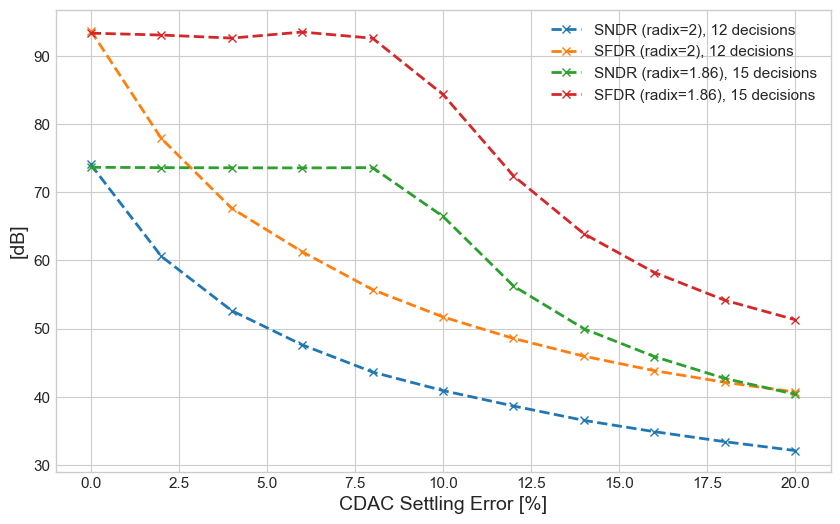

In [29]:
fig, ax = plt.subplots()
ax.plot(settling_error_pct, 20*np.log10(radix2_sndr), label='SNDR (radix=2), 12 decisions', marker='x', linestyle='dashed')
ax.plot(settling_error_pct, 20*np.log10(radix2_sfdr), label='SFDR (radix=2), 12 decisions', marker='x', linestyle='dashed')

ax.plot(settling_error_pct, 20*np.log10(subradix2_sndr), label='SNDR (radix=1.86), 15 decisions', marker='x', linestyle='dashed')
ax.plot(settling_error_pct, 20*np.log10(subradix2_sfdr), label='SFDR (radix=1.86), 15 decisions', marker='x', linestyle='dashed')
ax.legend()

ax.set_xlabel('CDAC Settling Error [%]')
ax.set_ylabel('[dB]')

## Prototyping SAR ADC Background Calibration Algorithms

As shown in the previous cells, PathSim provides a very nice interface to evaluate circuit architecture trade-offs in a highly controlled environment. 

As part of my SAR ADC project, I was interested in evaluating the feasibility of implementing a background calibration of the CDAC mismatch. I looked through many papers and found a quite simple solution, published by Liu, Huang, and Chiu in 2011 [IEEE Xplore Link](https://ieeexplore.ieee.org/document/5999734).

Their solution, called "Offset Double Conversion" performs two ADC conversions for each input sample and adds a different analog offset to the input for each conversion. If the ADC is linear (weights are correct), the difference between the two conversions will be equal to the analog offset and the average will be a conversion result that is linearly related to the input. However, if the ADC transfer characteristic is not linear, the difference between the two conversions is used to update the weights via LMS.

To evaluate the algorithm in PathSim, I created another block, dubbed the `CRSARCtrlODC`. This block listens to the output of the SAR ADC, waits until the `done` signal is asserted and then updates (1) the offset (`voffp` and `voffn`) applied to the analog input and (2) whether or not the ADC should sample a new input voltage (`samp_en`). The full list of I/O is given below (also see `crsar.py` for the entire implementation).

```
Inputs:
    sar_done: done signal from SAR ADC
    sar_dout: Data output from SAR ADC
    sar_dout_raw: Raw decisions from SAR ADC 
Outputs:
    odc_dout_offsetp: Data output for conversions with positive offset
    odc_dout_offsetn: Data output for conversions with negative offset
    odc_state: state of ODC controller
    sar_samp_en: drives samp_en of SAR ADC
    sar_vinp_offset: analog offset voltage for SAR (+) input
    sar_vinn_offset: analog offset voltage for SAR (-) input
    odc_dout_raw_offsetp: Raw decisions for conversions with positive offset
    odc_dout_raw_offsetn: Raw decisions for conversions with negative offset
```

The `odc_ctrl_demo.py` script operates the CRSARCtrlODC block by itself to illustrate the basic behavior of its state machine. 

The plots below show the behavior with analog offset voltages of 5 V and 10 V. As shown, the `samp_en` is asserted every other conversion and the analog offset flips between positive/negative polarities.

In [30]:
!python ./src/odc_ctrl_demo.py -a 5 -o ./data/odc_ctrl_offset5.csv > /dev/null
!python ./src/odc_ctrl_demo.py -a 10 -o ./data/odc_ctrl_offset10.csv > /dev/null

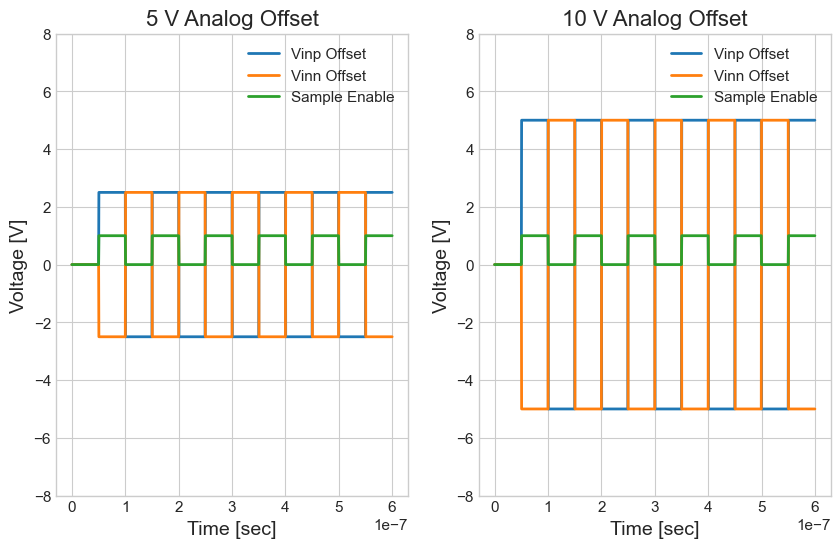

In [31]:
datafiles = ['./data/odc_ctrl_offset5.csv', './data/odc_ctrl_offset10.csv']
offset = ['5 V Analog Offset', '10 V Analog Offset']
fig, axs = plt.subplots(1, 2)

for i, df in enumerate(datafiles):
    
    dataset = np.genfromtxt(df, delimiter=',', skip_header=1)

    t = dataset[:, 0]
    vinp_offset = dataset[:, 1]
    vinn_offset = dataset[:, 2]
    samp_en = dataset[:, 3]
    odc_state = dataset[:, 4]

    axs[i].plot(t, vinp_offset, label='Vinp Offset')
    axs[i].plot(t, vinn_offset, label='Vinn Offset')
    axs[i].plot(t, samp_en, label='Sample Enable')
    axs[i].set_ylim([-8, 8])
    axs[i].set_title(offset[i])
    
    axs[i].legend()

    axs[i].set_xlabel('Time [sec]')
    axs[i].set_ylabel('Voltage [V]')

Next, a script was written to simulate the entire backgrond calibration algorithm. 

Since there are many more parameters in this script, a small `.toml` config file was used to provide a concise CLI.

Two simulations are performed below with an offset of 25 LSB and the same radix-1.86 weight vector:

* crsar_cal_get_block_offset25lsb_ideal.toml
    * actual and estimated weights and offset are equal (no CDAC non-linearity)
* crsar_cal_get_block_offset25lsb_nonideal.toml
    * actual and estimated weights and offset are NOT equal

These files can be examined in the `config` directory if desired. 

In [38]:
!python ./src/crsar_cal_get_block.py -c ./config/crsar_cal_get_block_offset25lsb_ideal.toml > /dev/null
!python ./src/crsar_cal_get_block.py -c ./config/crsar_cal_get_block_offset25lsb_nonideal.toml > /dev/null

First, the difference between the `offsetp` and `offsetn` conversions is evaluated for both conversions. 

With the ideal weights/offset, the difference oscillates around the ideal value of 50 LSB. 

However, for the case with non-ideal weights/offset, the difference spans from ~30 - 60 LSB!

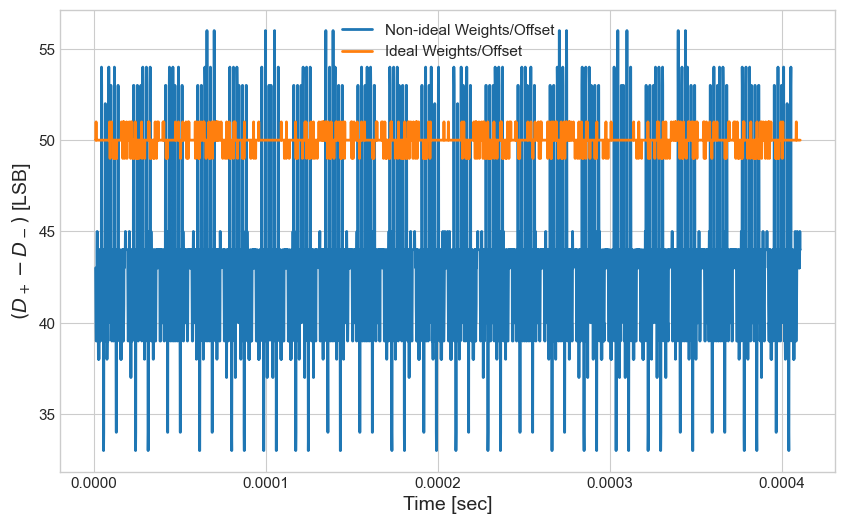

In [39]:
# manually compare diff of ADC outputs for both cases
datafiles = ['./data/cal_offset25lsb_nonideal.npz', './data/cal_offset25lsb_ideal.npz']
labels = ['Non-ideal Weights/Offset', 'Ideal Weights/Offset']

fig, ax = plt.subplots()
for i, df in enumerate(datafiles):
    
    dataset = np.load(df)
    t = dataset["time"]
    dout_offsetp = dataset["dout_offsetp"]
    dout_offsetn = dataset["dout_offsetn"]
    conv_diff = dout_offsetp - dout_offsetn

    ax.plot(t, conv_diff, label=labels[i])

    ax.legend()
    ax.set_xlabel('Time [sec]')
    ax.set_ylabel('$(d_+ - d_-)$ [LSB]')

If an FFT is performed for the estimated conversion result (average of `offsetp` and `offsetn` conversions), we see that the SFDR is degraded for the non-ideal case and several harmonics are visible in the spectrum.

Text(0, 0.5, 'FFT [dBFS]')

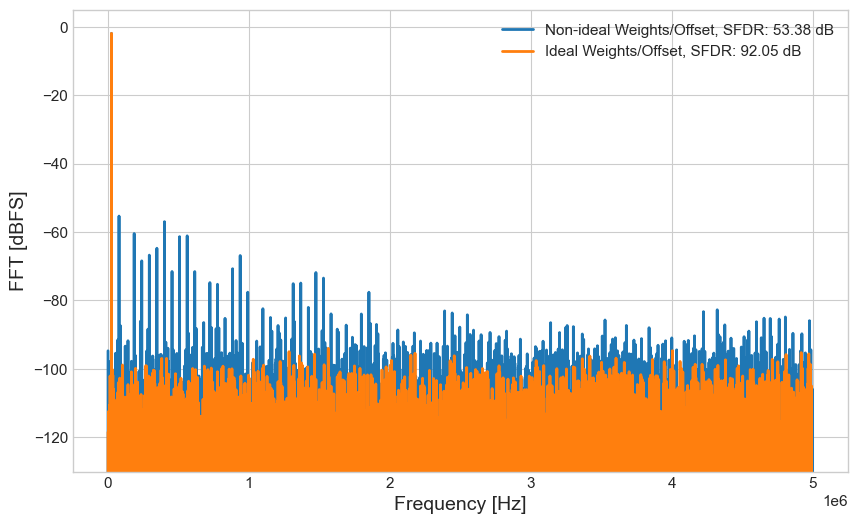

In [44]:
fig, ax = plt.subplots()
for i, df in enumerate(datafiles):
    
    dataset = np.load(df)
    dout_offsetp = dataset["dout_offsetp"]
    dout_offsetn = dataset["dout_offsetn"]
    conv_result = dout_offsetp*0.5 + dout_offsetn*0.5
    f, fft, sndr, sfdr = compute_dynamic_performance(conv_result, f_clk=10e6, N=4096, M=11)
    
    ax.plot(f, 20*np.log10(fft), label=f'{labels[i]}, SFDR: {20*np.log10(sfdr):.2f} dB')
    ax.set_ylim([-130, 5])
    ax.legend()

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('FFT [dBFS]')

Since the only error considered in these simulations is the capacitor mismatch (which is deterministic), this is no real utility in running several simulations to generate the batch LMS weight updates. Instead, the single data file from the above run is used to converge on the weights/offset that minimizes the ADC nonlinearities. This training loop is implemented in `src/odc_train_demo.py` which is run below. 

In [41]:
!python ./src/odc_train_demo.py \
-c ./config/crsar_cal_get_block_offset25lsb_nonideal.toml \
-d ./data/cal_offset25lsb_nonideal.npz \
-o ./data/cal_results_offset25lsb_nonideal.npz

The learning curve is presented in terms of the block SFDR. As shown, the LMS algorithm converges in roughly 4000 blocks and an SFDR > 90 dB is achieved! For this proof of concept, I used a constant learning rate for both the offset and weight vector updates (not optimized for any particular purpose). 

Text(0, 0.5, 'SFDR [dB]')

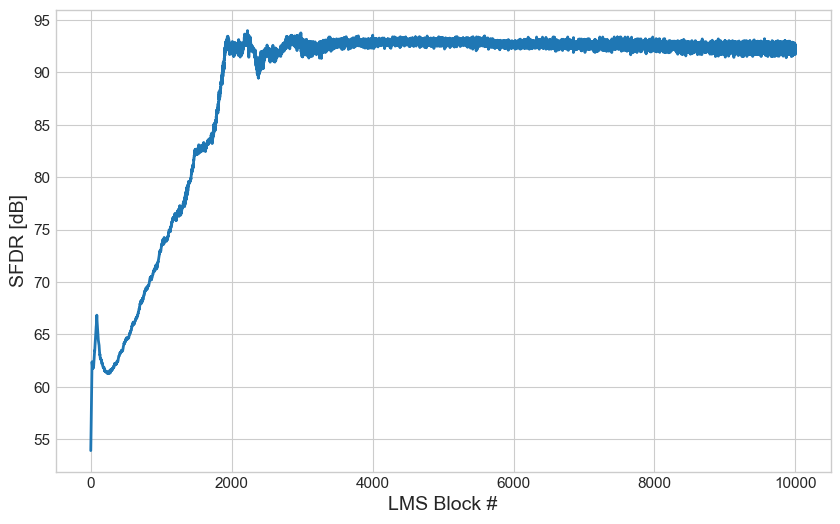

In [42]:
cal_results = np.load('./data/cal_results_offset25lsb_nonideal.npz')
fig, ax = plt.subplots()

ax.plot(20*np.log10(cal_results["sfdr_learning_curve"]))

ax.set_xlabel('LMS Block #')
ax.set_ylabel('SFDR [dB]')

The plot below shows the FFT before and after calibration. After calibration, the harmonics are removed from the spectrum and the SFDR improved by almost 40 dB!

Text(0, 0.5, 'FFT [dBFS]')

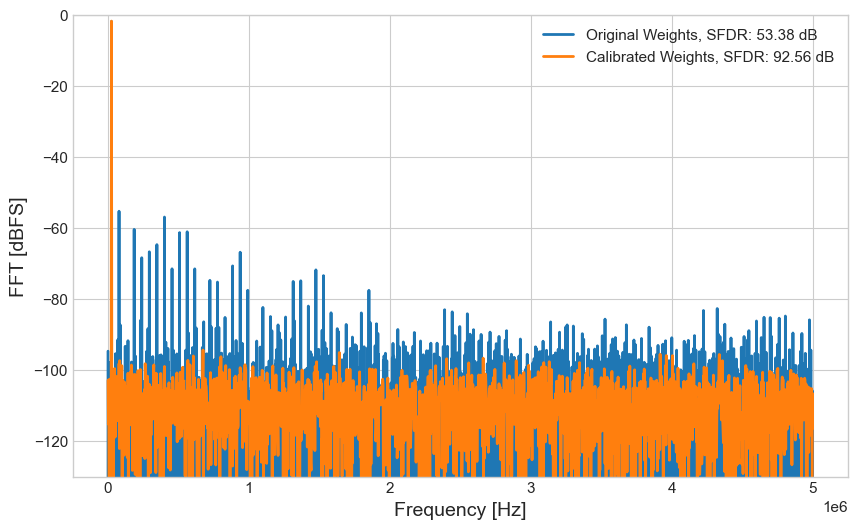

In [43]:
fig, ax = plt.subplots()

ax.plot(cal_results["fft_freq"], 20*np.log10(cal_results["fft_original"]), 
        label=f'Original Weights, SFDR: {20*np.log10(cal_results["sfdr_original"]):.2f} dB')
ax.plot(cal_results["fft_freq"], 20*np.log10(cal_results["fft_calibrated"]), 
        label=f'Calibrated Weights, SFDR: {20*np.log10(cal_results["sfdr_calibrated"]):.2f} dB')

ax.legend()
ax.set_ylim([-130, 0])

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('FFT [dBFS]')

## Summary/Future Work

Overall, this notebook showed the potential utility of PathSim for the open-source modeling of analog/mixed-signal circuits. Though this notebook examined the SAR ADC, PathSim could be used to model almost any circuit (supports continuous/discrete-time dynamics).

Through the process of implementing these models, I gained lots of intuition on the operation of both the SAR ADC and offset double conversion background calibration method. 

Future work could be done to determine how to partition the I/O interfaces of standard blocks (in my models, I ended up just adding more I/O as I needed it), modeling different circuits, and refining the SAR ADC model (e.g., effect of dynamic comparator offset, CDAC top-plate parasitics, comparator metastability, etc.). 

Thanks to the IEEE SSCS for the challenge to put this notebook together (was a tremendous learning experience!)